<a href="https://colab.research.google.com/github/Tapish0305/PCB-defect/blob/main/pcb_defect_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os
from tqdm import tqdm
import argparse
import glob
import xml.etree.ElementTree as ET
import cv2
import ast
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as immg
import random
import sys
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pickle

In [ ]:
path_an = "/kaggle/input/datasets/akhatova/pcb-defects/PCB_DATASET/Annotations"
dataset = {
            "xmin":[],
            "ymin":[],
            "xmax":[],
            "ymax":[],
            "class":[],
            "file":[],
            "width":[],
            "height":[],
           }
all_files = []
i = 0
for path, subdirs, files in os.walk(path_an):
    for name in files:
        all_files.append(os.path.join(path, name))

In [ ]:
for anno in all_files:
    tree = ET.parse(anno)
    for elem in tree.iter():
        if 'size' in elem.tag:
            for attr in list(elem):
                if 'width' in attr.tag:
                    width = int(round(float(attr.text)))
                if 'height' in attr.tag:
                    height = int(round(float(attr.text)))
        if 'object' in elem.tag:
            for attr in list(elem):
                if 'name' in attr.tag:
                    name = attr.text
                    dataset['class']+=[name]
                    dataset['width']+=[width]
                    dataset['height']+=[height]
                    dataset['file']+=[anno.split('/')[-1][0:-4]]

                if 'bndbox' in attr.tag:
                    for dim in list(attr):
                        if 'xmin' in dim.tag:
                            xmin = int(round(float(dim.text)))
                            dataset['xmin']+=[xmin]
                        if 'ymin' in dim.tag:
                            ymin = int(round(float(dim.text)))
                            dataset['ymin']+=[ymin]
                        if 'xmax' in dim.tag:
                            xmax = int(round(float(dim.text)))
                            dataset['xmax']+=[xmax]
                        if 'ymax' in dim.tag:
                            ymax = int(round(float(dim.text)))
                            dataset['ymax']+=[ymax]

In [ ]:
data=pd.DataFrame(dataset)
data

,xmin,ymin,xmax,ymax,class,file,width,height
0,1199,966,1234,1004,mouse_bite,01_mouse_bite_11,3034,1586
1,2042,755,2073,786,mouse_bite,01_mouse_bite_11,3034,1586
2,1472,607,1507,639,mouse_bite,01_mouse_bite_11,3034,1586
3,2168,854,2200,887,mouse_bite,01_mouse_bite_17,3034,1586
4,1513,919,1545,957,mouse_bite,01_mouse_bite_17,3034,1586
...,...,...,...,...,...,...,...,...
2948,706,892,741,991,spurious_copper,06_spurious_copper_09,2868,2316
2949,1055,1136,1114,1171,spurious_copper,06_spurious_copper_09,2868,2316
2950,1796,1019,1839,1089,spurious_copper,04_spurious_copper_04,3056,2464
2951,474,1236,527,1382,spurious_copper,04_spurious_copper_04,3056,2464


In [ ]:
data2 = data.copy()

In [ ]:
df = data.copy()
train, test = train_test_split(data, shuffle=True, test_size=0.2, random_state=34)

In [ ]:
classes_la = {"missing_hole": 1, "mouse_bite": 2, "open_circuit":3, "short": 4, 'spur': 5,'spurious_copper':6}
df["class"] = df["class"].apply(lambda x: classes_la[x])
train["class"] = train["class"].apply(lambda x: classes_la[x])
test["class"] = test["class"].apply(lambda x: classes_la[x])

In [ ]:
print("Data Frame Size ", len(df))
print("Train Size ", len(train))
print("Test Size ", len(test))

Data Frame Size  2953
Train Size  2362
Test Size  591


In [ ]:
def plot_image(image_name):
    print(image_name)
    image_group = data.groupby("file").get_group(image_name)
    bbox = image_group.loc[:,['xmin', 'ymin', 'xmax', 'ymax']]
    path ="/kaggle/input/pcb-defects/PCB_DATASET/images/"
    if "missing" in name.split('_'):
        path += 'Missing_hole/'
    if "mouse" in name.split('_'):
        path += 'Mouse_bite/'
    if "open" in name.split('_'):
        path += 'Open_circuit/'
    if "short" in name.split('_'):
        path += 'Short/'
    if "spur" in name.split('_'):
        path += 'Spur/'
    if "spurious" in name.split('_'):
        path += 'Spurious_copper/'

    img = immg.imread(path+""+name+'.jpg')
    fig,ax = plt.subplots(figsize=(18,10))
    ax.imshow(img,cmap='binary')
    for i in range(len(bbox)):
        box = bbox.iloc[i].values
        x,y,w,h = box[0], box[1], box[2]-box[0], box[3]-box[1]
        rect = matplotlib.patches.Rectangle((x,y),w,h,linewidth=1,edgecolor='r',facecolor='none',)
        ax.add_patch(rect)
    plt.show()

In [ ]:
class fcbData(object):
    def __init__(self, df, IMG_DIR, transforms):
        self.df = df
        self.img_dir = IMG_DIR
        self.image_ids = self.df['file'].unique().tolist()
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        a = ''
        if "missing" in image_id.split('_'):
            a = 'Missing_hole/'
        elif "mouse" in image_id.split('_'):
            a = 'Mouse_bite/'
        elif "open" in image_id.split('_'):
            a = 'Open_circuit/'
        elif "short" in image_id.split('_'):
            a = 'Short/'
        elif "spur" in image_id.split('_'):
            a = 'Spur/'
        elif "spurious" in image_id.split('_'):
            a = 'Spurious_copper/'
        image_values = self.df[self.df['file'] == image_id]
        image = cv2.imread(self.img_dir+a+image_id+".jpg",cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32)
        image /= 255.0

        boxes = image_values[['xmin', 'ymin', 'xmax', 'ymax']].to_numpy()
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        labels = image_values["class"].values
        labels = torch.tensor(labels)

        target = {}
        target['boxes'] = boxes
        target['labels'] = torch.as_tensor(labels, dtype=torch.int64)
        target['image_id'] = torch.tensor([idx])
        target['area'] = torch.as_tensor(area, dtype=torch.float32)
        target['iscrowd'] = torch.zeros(len(classes_la), dtype=torch.int64)

        if self.transforms:
            sample = {
                'image': image,
                'bboxes': target['boxes'],
                'labels': labels.tolist()
            }

            sample = self.transforms(**sample)
            image = sample['image']
            target['boxes'] = torch.stack(tuple(map(torch.tensor, zip(*sample['bboxes'])))).permute(1, 0)

        return torch.tensor(image), target, image_id

In [ ]:
def get_train_transform():
    return A.Compose([
        ToTensorV2(p=1.0)
    ], bbox_params={'format': 'pascal_voc', 'label_fields': ['labels']})

def get_valid_transform():
    return A.Compose([
        ToTensorV2(p=1.0)
    ], bbox_params={'format': 'pascal_voc', 'label_fields': ['labels']})
def get_test_transform():
    return A.Compose([
        ToTensorV2(p=1.0)
    ], bbox_params={'format': 'pascal_voc', 'label_fields': ['labels']})

In [ ]:
path ="/kaggle/input/datasets/akhatova/pcb-defects/PCB_DATASET/images/"
fcb_dataset   = fcbData(df, path, get_train_transform())

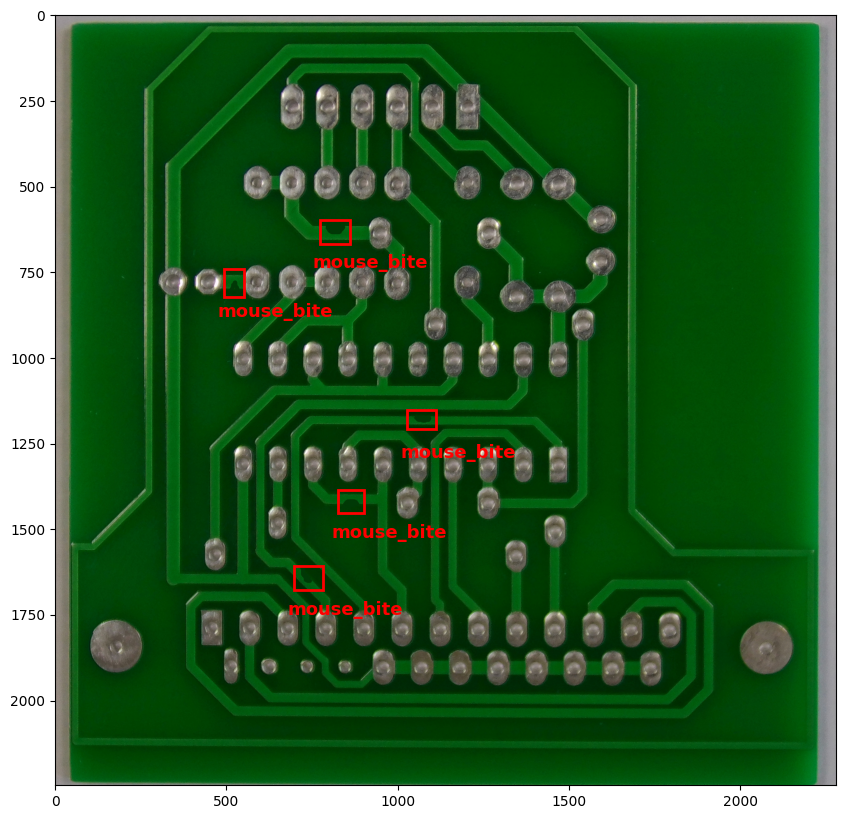

In [ ]:
img, tar, _ = fcb_dataset[random.randint(0,50)]
bbox = tar['boxes']
fig,ax = plt.subplots(figsize=(18,10))
ax.imshow(img.permute(1,2,0).cpu().numpy())
for j in tar["labels"]:
    classes_la = {1:"missing_hole", 2: "mouse_bite", 3:"open_circuit",4: "short", 5:'spur',6:'spurious_copper'}
    l = classes_la[int(j)]
    for i in range(len(bbox)):
        box = bbox[i]
        x,y,w,h = box[0], box[1], box[2]-box[0], box[3]-box[1]
        rect = matplotlib.patches.Rectangle((x,y),w,h,linewidth=2,edgecolor='r',facecolor='none',)
        ax.text(x-20, y+100, l, verticalalignment='top', color='red', fontsize=13, weight='bold')
        ax.add_patch(rect)
    plt.show()

In [ ]:
valid_df = train.sample(frac=0.1, random_state=42)
indices_to_remove = valid_df.index
train_df = train.drop(indices_to_remove)
test_df = test
train_df.shape,valid_df.shape

((2126, 8), (236, 8))

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
train_dataset = fcbData(train_df, path, get_train_transform())
valid_dataset = fcbData(valid_df, path, get_valid_transform())
test_dataset  = fcbData(test_df , path, get_test_transform())

# split the dataset in train and test set
indices = torch.randperm(len(train_dataset)).tolist()

train_data_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=6,
    collate_fn=collate_fn
)

valid_data_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=6,
    collate_fn=collate_fn
)

test_data_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=6,
    collate_fn=collate_fn
)

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision.models import vgg16, VGG16_Weights
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

class VGG16Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(vgg.features.children())[:-1])
        self.out_channels = 512

    def forward(self, x):
        return {'0': self.features(x)}

def load_model():
    num_classes = 7
    backbone = VGG16Backbone()
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    # ROI Pooler
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    # Build FasterRCNN
    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=256,
        max_size=256
    )
    return model

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print("Using device ",device)

Using device  cpu


In [ ]:
torch.cuda.empty_cache()

## Pseudo Code

In [ ]:
# layer_names = ["roi_heads.box_head.fc6","roi_heads.box_head.fc7"]
# layer = dict([*model.named_modules()])[layer_names[1]]
# features = []
# def hook_fn(module, input, output):
#         features.append(output)
# handle = layer.register_forward_hook(hook_fn)
# sample_image.requires_grad_(True)
# model.zero_grad()
# features.clear()
# model.eval()
# out = model(sample_image)
# model.train()
# F_ml = features[0]

In [ ]:
# F_ml.size()
# spatial_size = sample_image.shape[-1] * sample_image.shape[-2]
# C = F_ml.shape[0]
# S_l = torch.zeros((C, spatial_size), device=sample_image.device)

In [ ]:
# for c in range(C):
#     model.zero_grad()
#     if sample_image.grad is not None:
#         sample_image.grad.zero_()

#     activation_scalar = F_ml[c].mean()
#     # print(f"activation_scalar grad_fn: {activation_scalar.grad_fn}")  # should NOT be None

#     activation_scalar.backward(retain_graph=True)

#     # print(f"sample_image.grad is None: {sample_image.grad is None}")  # should be False
#     # print(f"grad sum: {sample_image.grad.sum()}")                      # should NOT be 0

#     grad = sample_image.grad.detach().clone()
#     grad_mag = grad.pow(2).sum(dim=1).sqrt()
#     grad_flat = grad_mag.view(-1)
#     S_l[c, :] = grad_flat
#     del grad, grad_mag, grad_flat, activation_scalar
#     torch.cuda.empty_cache()

In [ ]:
# import gc


# del out
# gc.collect()
# torch.cuda.empty_cache()
# features = S_l.cpu().float()
# features_centered = features - features.mean(dim=1, keepdim=True)
# G = features.size(1)
# K = torch.matmul(features_centered, features_centered.t()) / G
# diag_K = torch.diag(K)
# diag_inv_sqrt = torch.diag(1.0 / torch.sqrt(diag_K + 1e-6))
# corr_matrix = torch.matmul(diag_inv_sqrt, torch.matmul(K, diag_inv_sqrt))
# mask = ~torch.eye(corr_matrix.size(0), dtype=torch.bool, device=features.device)
# mean_corr_l = corr_matrix.abs()[mask].view(corr_matrix.size(0), -1).max(dim=1)[0].mean()
# mean_corr_l = mean_corr_l.to(device)
# print(f"mean_corr_l: {mean_corr_l.item():.6f}")
# del features, features_centered, K, diag_K, diag_inv_sqrt, corr_matrix, mask
# gc.collect()

# FINAL CODE

In [ ]:
def compute_saliency_matrix(model, sample_image, layer_name):
    """
    Computes the Saliency Matrix S_l for a given layer using gradient-based
    saliency mapping, as described in Section II-A of the paper.

    For each filter/channel c in the layer, the gradient of the mean activation
    with respect to the input image is computed. This gradient captures how much
    each spatial location in the input influences that filter's activation —
    if two filters produce similar gradients, they are learning correlated features.

    The resulting saliency matrix S_l has shape [G, CHW] where:
        G   = number of filters/channels in the layer
        CHW = flattened spatial dimension of the input image

    This S_l is then passed to compute_pearson_weight_correlation() to estimate
    the mean feature correlation (Equations 1-3 in paper).

    Args:
        model                   : The Faster R-CNN model (must be in train mode
                                  to allow gradient computation).
        sample_image (Tensor)   : Input image tensor of shape [1, 3, H, W].
                                  Batch size must be 1.
        layer_name   (str)      : Name of the ROI head layer to compute saliency
                                  for. Example: 'roi_heads.box_head.fc6'

    Returns:
        S_l (Tensor)            : Saliency matrix of shape [C, spatial_size]
                                  where C = number of filters in the layer and
                                  spatial_size = H * W of the input image.

    Note:
        - handle.remove() must be called to detach the forward hook after use,
          preventing memory leaks across training iterations.
        - retain_graph=True is required in backward() since we compute gradients
          for each filter c in a loop over the same computation graph.
    """
    layer = dict([*model.named_modules()])[layer_name]
    features = []
    def hook_fn(module, input, output):
            features.append(output)
    handle = layer.register_forward_hook(hook_fn)
    sample_image.requires_grad_(True)
    model.zero_grad()
    features.clear()
    model.train()
    out = model(sample_image)
    F_ml = features[0]
    spatial_size = sample_image.shape[-1] * sample_image.shape[-2]
    C = F_ml.shape[0]
    S_l = torch.zeros((C, spatial_size), device=sample_image.device)
    for c in range(C):
        model.zero_grad()
        if sample_image.grad is not None:
            sample_image.grad.zero_()

        activation_scalar = F_ml[c].mean()
        activation_scalar.backward(retain_graph=True)
        grad = sample_image.grad.detach().clone()
        grad_mag = grad.pow(2).sum(dim=1).sqrt()
        grad_flat = grad_mag.view(-1)
        S_l[c, :] = grad_flat
        del grad, grad_mag, grad_flat, activation_scalar
        torch.cuda.empty_cache()
    del out
    handle.remove()
    gc.collect()
    torch.cuda.empty_cache()
    return S_l

In [ ]:
import torch

def compute_pearson_weight_correlation(features):
    """
    Computes Pearson Correlation Matrix and Mean Correlation Score.
    Args:
        features: Tensor of shape [G, D]
                  G = number of filters, D = flattened spatial dimension
    Returns:
        mean_corr_l: scalar, mean of max off-diagonal correlations per row
                     (matches Equation 3 in paper)
        corr_matrix: [G x G] Pearson correlation matrix
    """
    features_centered = features - features.mean(dim=1, keepdim=True)
    G = features.size(0)
    K = torch.matmul(features_centered, features_centered.t()) / G
    diag_K = torch.diag(K)
    diag_inv_sqrt = torch.diag(1.0 / torch.sqrt(diag_K + 1e-6))
    corr_matrix = torch.matmul(diag_inv_sqrt, torch.matmul(K, diag_inv_sqrt))
    mask = ~torch.eye(corr_matrix.size(0), dtype=torch.bool, device=features.device)
    mean_corr_l = corr_matrix.abs()[mask].view(corr_matrix.size(0), -1).max(dim=1)[0].mean()
    mean_corr_l = mean_corr_l.to(device)
    print(f"mean_corr_l: {mean_corr_l.item():.6f}")
    del features, features_centered, K, diag_K, diag_inv_sqrt, corr_matrix, mask
    gc.collect()
    return mean_corr_l

In [ ]:
def orthogonality_computation(model, lembda, device, layer_names, correlation_flags):
    """
    Computes the Orthogonal Regularization Loss for selected ROI Head layers.

    This function implements the soft orthogonal loss described in Equation (8)
    of the paper "PCB Defect Detection using Adaptive Orthogonal Deep Neural
    Network". The loss penalizes deviation of the filter weight matrix from
    semi-orthogonality using the Frobenius norm, and is applied ONLY to those
    ROI head layers whose mean Pearson correlation exceeds the threshold (i.e.,
    correlation_flag == 1), avoiding unnecessary backpropagation overhead on
    uncorrelated layers.

    Formula:
        L_orth = lambda * sum_l || W_l^T * W_l - I ||_F ^ 2  (if s1 >= s2)
        L_orth = lambda * sum_l || W_l * W_l^T - I ||_F ^ 2  (if s1 < s2)

    Args:
        model              : The Faster R-CNN model being trained.
        lembda     (float) : Regularization constant (lambda) that controls the
                             strength of orthogonality. Best value per paper: 0.001.
        device             : torch.device — 'cuda' or 'cpu'.
        layer_names  (list): List of ROI head layer name strings to consider.
                             Example: ['roi_heads.box_head.fc6',
                                       'roi_heads.box_head.fc7']
        correlation_flags (list): List of 1/0 flags corresponding to layer_names.
                             1 = mean correlation exceeded threshold (apply loss),
                             0 = mean correlation below threshold (skip layer).

    Returns:
        extra_norm (float) : Scaled orthogonal loss value = lambda * Frobenius norm.
                             Returns 0.0 if no layer has correlation_flag == 1.
    """
    extra_norm = 0.
    for name, flag in zip(layer_names, correlation_flags):
        if flag == 1:
            m = dict(model.named_modules())[name]
            tmp = m.weight.view(m.weight.data.size(0), -1)
            s1, s2 = tmp.shape
            if s1 < s2:
                extra_norm += torch.norm(
                    torch.mm(tmp, tmp.t()) - torch.eye(s1).to(device),
                    p='fro'
                ).pow(2)
            else:
                extra_norm += torch.norm(
                    torch.mm(tmp.t(), tmp) - torch.eye(s2).to(device),
                    p='fro'
                ).pow(2)
    return lembda * extra_norm

In [ ]:
## code final
import torch
import torchvision
import numpy as np
import pickle
from tqdm import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lembdas = [0, 0.0001, 0.001, 0.01]
IOU_curves = []
loss_curves = []
models = []
for lembda in lembdas:
    num_epochs = 25
    loss_curve_in = []
    IOU_curve = []
    loss_curve_out = []
    model = load_model().to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params, lr=0.0001, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=3, gamma=0.1
    )
    layer_names = [
        "roi_heads.box_head.fc6",
        "roi_heads.box_head.fc7"
    ]
    for epoch in range(num_epochs):
        model.train()
        tk = tqdm(train_data_loader, desc=f"Lambda={lembda} Epoch={epoch+1}")
        running_loss = 0.0
        for images, targets, image_id in tk:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            mean_correlation = []
            list_apply_orth = []
            for layer_name in layer_names:
                S_l = compute_saliency_matrix(model, images[0].unsqueeze(0), layer_name)
                mean_corr = compute_pearson_weight_correlation(S_l.cpu().float())
                apply_orth = mean_corr > 0.3
                list_apply_orth.append(apply_orth)
            loss_dict = model(images, targets)
            L_theta = sum(loss for loss in loss_dict.values())
            L_orth = orthogonality_computation(model, lembda, device, layer_names, list_apply_orth)
            L_orth_val = L_orth.item() if isinstance(L_orth, torch.Tensor) else L_orth
            Total_Loss = L_theta + L_orth
            optimizer.zero_grad()
            Total_Loss.backward()
            optimizer.step()
            running_loss += Total_Loss.item()
            loss_curve_in.append(Total_Loss.item())
            tk.set_postfix(
                L_theta=round(L_theta.item(), 4),
                L_orth=round(L_orth_val, 4),
            )
        running_loss /= len(train_data_loader)
        loss_curve_out.append(running_loss)
        lr_scheduler.step()
        print(f"Lambda={lembda} | Epoch #{epoch+1} | Mean Loss: {running_loss:.4f}")
        # --- Validation ---
        model.eval()
        with torch.no_grad():
            tk = tqdm(valid_data_loader, desc="Validation")
            running_IOU = 0.0
            IOU_curve
            for images, targets, image_ids in tk:
                images = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                val_output = model(images)
                IOU = []
                for j in range(len(val_output)):
                    a = val_output[j]['boxes'].cpu().detach()
                    b = targets[j]['boxes'].cpu().detach()
                    chk = torchvision.ops.box_iou(a, b)
                    res = np.nanmean((chk.sum(axis=1) / denom).numpy())
                    if np.isnan(res):
                        res = 0.0
                    IOU.append(res)
                running_IOU += np.nanmean(IOU)
                tk.set_postfix(IoU=round(np.nanmean(IOU)))
            running_IOU /= len(valid_data_loader)
            IOU_curve.append(running_IOU)
            print(f"Validation IOU: {running_IOU:.4f}")
        torch.cuda.empty_cache()
    IOU_curves.append(IOU_curve)
    loss_curves.append(loss_curve_out)
    models.append(model)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

lembdas = [0, 0.0001, 0.001, 0.01]
colors = ['blue', 'green', 'red', 'orange']

# --- Plot 1: Loss Curves ---
plt.figure(figsize=(10, 5))
for i, lembda in enumerate(lembdas):
    epochs = range(1, len(loss_curves[i]) + 1)
    plt.plot(epochs, loss_curves[i], color=colors[i], label=f'λ={lembda}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve for Different λ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()

# --- Plot 2: IOU Curves ---
plt.figure(figsize=(10, 5))
for i, lembda in enumerate(lembdas):
    epochs = range(1, len(IOU_curves[i]) + 1)
    plt.plot(epochs, IOU_curves[i], color=colors[i], label=f'λ={lembda}')

plt.xlabel('Epoch')
plt.ylabel('IOU')
plt.title('Validation IOU Curve for Different λ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('IOU_curves.png', dpi=150)
plt.show()

# --- Plot 3: Loss + IOU side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, lembda in enumerate(lembdas):
    epochs = range(1, len(loss_curves[i]) + 1)
    axes[0].plot(epochs, loss_curves[i], color=colors[i], label=f'λ={lembda}')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

for i, lembda in enumerate(lembdas):
    epochs = range(1, len(IOU_curves[i]) + 1)
    axes[1].plot(epochs, IOU_curves[i], color=colors[i], label=f'λ={lembda}')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IOU')
axes[1].set_title('Validation IOU')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('ODNN Training Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_summary.png', dpi=150)
plt.show()

# --- Print Best Results ---
print("\n===== Best Results =====")
for i, lembda in enumerate(lembdas):
    best_iou = max(IOU_curves[i])
    best_epoch = IOU_curves[i].index(best_iou) + 1
    min_loss = min(loss_curves[i])
    print(f"λ={lembda} | Best IOU: {best_iou:.4f} (Epoch {best_epoch}) | Min Loss: {min_loss:.4f}")

## TESTING

In [ ]:
# import torch
# import torchvision
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# from tqdm import tqdm

# # PCB defect class names
# CLASS_NAMES = {
#     1: 'missing_hole',
#     2: 'mouse_bite',
#     3: 'open_circuit',
#     4: 'short',
#     5: 'spur',
#     6: 'spurious_copper'
# }

# COLORS = {
#     1: 'red',
#     2: 'blue',
#     3: 'green',
#     4: 'orange',
#     5: 'purple',
#     6: 'cyan'
# }

# def evaluate_on_test(model, test_data_loader, device, iou_threshold=0.5, score_threshold=0.5):
#     model.eval()

#     all_predictions = []
#     all_targets = []

#     running_iou = 0.0
#     total_tp = 0
#     total_fp = 0
#     total_fn = 0

#     # Per class metrics
#     class_tp = {k: 0 for k in CLASS_NAMES}
#     class_fp = {k: 0 for k in CLASS_NAMES}
#     class_fn = {k: 0 for k in CLASS_NAMES}

#     with torch.no_grad():
#         tk = tqdm(test_data_loader, desc="Testing")

#         for images, targets, image_ids in tk:
#             images = [img.to(device) for img in images]
#             targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

#             outputs = model(images)

#             for j in range(len(outputs)):
#                 pred_boxes   = outputs[j]['boxes'].cpu()
#                 pred_labels  = outputs[j]['labels'].cpu()
#                 pred_scores  = outputs[j]['scores'].cpu()

#                 gt_boxes     = targets[j]['boxes'].cpu()
#                 gt_labels    = targets[j]['labels'].cpu()

#                 # Filter by score threshold
#                 keep = pred_scores >= score_threshold
#                 pred_boxes  = pred_boxes[keep]
#                 pred_labels = pred_labels[keep]
#                 pred_scores = pred_scores[keep]

#                 all_predictions.append({
#                     'boxes':  pred_boxes,
#                     'labels': pred_labels,
#                     'scores': pred_scores
#                 })
#                 all_targets.append({
#                     'boxes':  gt_boxes,
#                     'labels': gt_labels
#                 })

#                 # IOU calculation
#                 if len(pred_boxes) > 0 and len(gt_boxes) > 0:
#                     iou_matrix = torchvision.ops.box_iou(pred_boxes, gt_boxes)
#                     iou_vals   = iou_matrix.max(dim=1).values
#                     running_iou += iou_vals.mean().item()

#                 # TP / FP / FN per class
#                 matched_gt = set()
#                 for pi in range(len(pred_boxes)):
#                     pred_cls = pred_labels[pi].item()
#                     matched  = False

#                     if len(gt_boxes) > 0:
#                         iou_matrix = torchvision.ops.box_iou(
#                             pred_boxes[pi].unsqueeze(0), gt_boxes
#                         )
#                         best_iou, best_idx = iou_matrix[0].max(0)

#                         if (best_iou >= iou_threshold and
#                             best_idx.item() not in matched_gt and
#                             gt_labels[best_idx].item() == pred_cls):

#                             total_tp += 1
#                             class_tp[pred_cls] = class_tp.get(pred_cls, 0) + 1
#                             matched_gt.add(best_idx.item())
#                             matched = True

#                     if not matched:
#                         total_fp += 1
#                         class_fp[pred_cls] = class_fp.get(pred_cls, 0) + 1

#                 # FN - missed ground truths
#                 for gi in range(len(gt_boxes)):
#                     if gi not in matched_gt:
#                         total_fn += 1
#                         gt_cls = gt_labels[gi].item()
#                         class_fn[gt_cls] = class_fn.get(gt_cls, 0) + 1

#     # Overall metrics
#     running_iou /= len(test_data_loader)
#     precision    = total_tp / (total_tp + total_fp + 1e-6)
#     recall       = total_tp / (total_tp + total_fn + 1e-6)
#     f1           = 2 * precision * recall / (precision + recall + 1e-6)

#     # Print results
#     print("\n" + "="*55)
#     print("         PCB DEFECT DETECTION - TEST RESULTS")
#     print("="*55)
#     print(f"  Mean IOU        : {running_iou:.4f}")
#     print(f"  Precision       : {precision:.4f}")
#     print(f"  Recall          : {recall:.4f}")
#     print(f"  F1 Score        : {f1:.4f}")
#     print(f"  Total TP        : {total_tp}")
#     print(f"  Total FP        : {total_fp}")
#     print(f"  Total FN        : {total_fn}")
#     print("="*55)
#     print("\n  Per-Class Results:")
#     print(f"  {'Class':<20} {'TP':>5} {'FP':>5} {'FN':>5} {'Prec':>8} {'Rec':>8}")
#     print("  " + "-"*53)

#     for cls_id, cls_name in CLASS_NAMES.items():
#         tp   = class_tp.get(cls_id, 0)
#         fp   = class_fp.get(cls_id, 0)
#         fn   = class_fn.get(cls_id, 0)
#         prec = tp / (tp + fp + 1e-6)
#         rec  = tp / (tp + fn + 1e-6)
#         print(f"  {cls_name:<20} {tp:>5} {fp:>5} {fn:>5} {prec:>8.4f} {rec:>8.4f}")

#     print("="*55)

#     return all_predictions, all_targets


# def visualize_predictions(model, test_data_loader, device,
#                           score_threshold=0.5, num_images=5):
#     model.eval()
#     shown = 0

#     with torch.no_grad():
#         for images, targets, image_ids in test_data_loader:
#             if shown >= num_images:
#                 break

#             images  = [img.to(device) for img in images]
#             targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
#             outputs = model(images)

#             for j in range(len(outputs)):
#                 if shown >= num_images:
#                     break

#                 img = images[j].cpu().permute(1, 2, 0).numpy()
#                 img = (img - img.min()) / (img.max() - img.min())  # normalize

#                 pred_boxes  = outputs[j]['boxes'].cpu()
#                 pred_labels = outputs[j]['labels'].cpu()
#                 pred_scores = outputs[j]['scores'].cpu()
#                 gt_boxes    = targets[j]['boxes'].cpu()
#                 gt_labels   = targets[j]['labels'].cpu()

#                 # Score filter
#                 keep        = pred_scores >= score_threshold
#                 pred_boxes  = pred_boxes[keep]
#                 pred_labels = pred_labels[keep]
#                 pred_scores = pred_scores[keep]

#                 fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#                 # --- Ground Truth ---
#                 axes[0].imshow(img)
#                 axes[0].set_title('Ground Truth', fontsize=12)
#                 for bi in range(len(gt_boxes)):
#                     x1, y1, x2, y2 = gt_boxes[bi]
#                     cls_id   = gt_labels[bi].item()
#                     cls_name = CLASS_NAMES.get(cls_id, f'class_{cls_id}')
#                     color    = COLORS.get(cls_id, 'white')
#                     rect     = patches.Rectangle(
#                         (x1, y1), x2-x1, y2-y1,
#                         linewidth=2, edgecolor=color, facecolor='none'
#                     )
#                     axes[0].add_patch(rect)
#                     axes[0].text(
#                         x1, y1-5, cls_name,
#                         color=color, fontsize=8, fontweight='bold',
#                         bbox=dict(facecolor='black', alpha=0.5, pad=1)
#                     )
#                 axes[0].axis('off')

#                 # --- Predictions ---
#                 axes[1].imshow(img)
#                 axes[1].set_title('Predictions', fontsize=12)
#                 for bi in range(len(pred_boxes)):
#                     x1, y1, x2, y2 = pred_boxes[bi]
#                     cls_id   = pred_labels[bi].item()
#                     score    = pred_scores[bi].item()
#                     cls_name = CLASS_NAMES.get(cls_id, f'class_{cls_id}')
#                     color    = COLORS.get(cls_id, 'white')
#                     rect     = patches.Rectangle(
#                         (x1, y1), x2-x1, y2-y1,
#                         linewidth=2, edgecolor=color, facecolor='none'
#                     )
#                     axes[1].add_patch(rect)
#                     axes[1].text(
#                         x1, y1-5, f'{cls_name}: {score:.2f}',
#                         color=color, fontsize=8, fontweight='bold',
#                         bbox=dict(facecolor='black', alpha=0.5, pad=1)
#                     )
#                 axes[1].axis('off')

#                 plt.suptitle(f'Image ID: {image_ids[j]}', fontsize=13)
#                 plt.tight_layout()
#                 plt.savefig(f'prediction_{shown+1}.png', dpi=150, bbox_inches='tight')
#                 plt.show()
#                 shown += 1


# # =====================
# #       RUN
# # =====================

# # Best model select karo (λ=0.001 paper ke according)
# best_model_idx = lembdas.index(0.001)
# best_model     = models[best_model_idx].to(device)

# # Evaluate
# all_preds, all_targets = evaluate_on_test(
#     best_model,
#     test_data_loader,
#     device,
#     iou_threshold=0.5,
#     score_threshold=0.5
# )

# # Visualize
# visualize_predictions(
#     best_model,
#     test_data_loader,
#     device,
#     score_threshold=0.5,
#     num_images=5
# )
